# Big Data Analytics and Text Minig Project

### Tommaso Bergonzoni & Ivo Rimbaldi

# Motivation

# Set up

Installing corrected versions of libraries

In [ ]:
!pip install -q --upgrade "pillow<11.0.0" transformers>=4.45.0 accelerate torchao scikit-learn tqdm chess cairosvg python-Levenshtein datasets peft huggingface_hub

Importing libraries

In [ ]:
# Standard library imports
from collections import Counter
import gc
import json
import os
from pathlib import Path
import shutil
import subprocess
import sys

# Third-party library imports
from datasets import load_dataset
from functools import partial
from huggingface_hub import HfApi, notebook_login
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from peft import LoraConfig, PeftModel, TaskType, get_peft_model
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from tqdm import tqdm
from transformers import (
    AutoModelForImageTextToText,
    AutoProcessor,
    Trainer,
    TrainingArguments,
)



Environment set up : github repo cloning and importing functions/class from different files inside the repo

In [ ]:
# Project configuration dictionary
CONFIG = {
    "colab": True,
    "branch": "main",
    "repo_name": "BigDataAndTextMiningProject",
    "repo_owner": "Aivon99",
    "repo_dir": "/content/BigDataAndTextMiningProject",
}

# Setup repository path and Hugging Face name
repo_root = Path(CONFIG["repo_dir"])
ORGANIZATION_NAME = "bdatm-project"

if CONFIG["colab"]:
    # If the repository folder already exists, reference it safely
    if repo_root.exists():
        print(f"Repository directory already exists at: {repo_root}")
    else:
        auth_url = "https://"
        repo_url = f"{auth_url}github.com/{CONFIG['repo_owner']}/{CONFIG['repo_name']}.git"

        print(f"Cloning repository from {repo_url}...")
        result = subprocess.run(
            ["git", "clone", "--single-branch", "--branch", CONFIG["branch"], repo_url, str(repo_root)],
            capture_output=True, text=True
        )
        assert result.returncode == 0, f"Git clone failed: {result.stderr}"
else:
    repo_root = Path(".").resolve().parent.parent


print(f"Setup Complete. REPO_ROOT: {repo_root}")

# Check GPU and device availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Configure system paths for absolute module imports
sys.path.insert(0, str(repo_root))
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root / "src" / "data"))
sys.path.insert(0, str(repo_root / "src" / "eval"))

# Import custom project modules cleanly
from data.generation import (
    build_sample,
    generate_dataset,
)

from data.utilities import (
    load_lichess_csv,
    upload_dataset_to_hub,
    authenticate_hf,
)

from eval.utilities import (
   calculate_fen_exact_match,
   calculate_levenshtein_metrics,
   calculate_square_by_square_accuracy,
   evaluate_chessboard_model_task_1,
   evaluate_chessboard_model_task_2,
   evaluate_chessboard_model_task_3,
   preprocess_function,
   get_patch_reordering_indices,
   reorder_chessboard_image,
   finetune_and_push_chessboard_model,
   Qwen35VisionDataCollator
)

print("All custom modules and eval utilities imported successfully!")


# Dataset

### Dataset Creation

We use "lichess_db_puzzle.csv" dataset to create our dataset

Loading dataset

In [ ]:
csv_path = Path("lichess_db_puzzle.csv")
zst_path = Path("lichess_db_puzzle.csv.zst")

if not csv_path.exists():
  # 1. Ensure zstd system tool is installed in Colab
  if shutil.which("zstd") is None and shutil.which("unzstd") is None:
    print("Installing zstd decompression tool...")
    !apt-get update -qq && apt-get install -y zstd -qq

  # 2. Download compressed dataset if not present
  if not zst_path.exists():
    print("Downloading Lichess puzzles database ...")
    !wget -q --show-progress https://database.lichess.org/lichess_db_puzzle.csv.zst

  # 3. Decompress to CSV and remove the archive
  print("Decompressing archive )...")
  !unzstd -f --rm lichess_db_puzzle.csv.zst -o lichess_db_puzzle.csv

  # 4. Clean up any leftover duplicate downloads
  !rm -f lichess_db_puzzle.csv.zst.*

  print("Decompression complete!")
else:
  print(f"'{csv_path}' already exists.")

lichess_db_puzzle.c 100%[===================>] 290.28M  34.1MB/s    in 9.4s    
Decompressing archive (~1.5 GB CSV)...
lichess_db_puzzle.csv.zst: 1129374135 bytes 
Decompression complete!


Defining constants to set the size of the datasets:

(You can set the following variables to a small number to test the whole notebook in an reasonable time)

In [ ]:
#To modify, just to test
MAX_SAMPLES = 100
N_WHITE_BLACK = 20

#IMPORTANT  ---->  MAX_SAMPLES must be lightly greater than N_WHITE_BLACK * 2

# ( for instance : 2000 White to move, 2000 Black to move -> 4000 total)

Loading the correct number of samples (black and white moves)

In [ ]:
df_raw = load_lichess_csv(csv_path=csv_path, max_samples=MAX_SAMPLES)

# Extract the active turn from FEN for balancing ('w' or 'b')
df_raw["turn"] = df_raw["FEN"].apply(
    lambda f: f.split(" ")[1] if len(f.split(" ")) > 1 else "w"
)

# Sample black and white moves as defined by constant N_WHITE_BLACK
df_white = df_raw[df_raw["turn"] == "w"].sample(n=N_WHITE_BLACK, random_state=42)
df_black = df_raw[df_raw["turn"] == "b"].sample(n=N_WHITE_BLACK, random_state=42)

df_balanced = (
    pd.concat([df_white, df_black])
    .sample(frac=1.0, random_state=42)
    .reset_index(drop=True)
)

print(f"Balanced dataset loaded: {len(df_balanced)} total puzzles")
print(df_balanced["turn"].value_counts())

Stratified split : 80% (test) - 10% (train) - 10% (val)

In [ ]:
train_df, temp_df = train_test_split(
    df_balanced, test_size=0.20, random_state=42, stratify=df_balanced["turn"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["turn"]
)

splits = {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}

print(f"Split sizes: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")

Creating dataset using the function ***generate_dataset()*** defined in *src/data/generation.py*. This function generates the dataset for each of the three task depending on the argument passed in it.

In [ ]:
tasks = ["task1", "task2", "task3"]

for task in tasks:
    print(f"\n==================== GENERATING {task.upper()} ====================")
    for split_name, split_df in splits.items():
        output_dir = f"dataset_{task}/{split_name}"

        # Remove existing directory and its contents if present
        #if os.path.exists(output_dir):
            #shutil.rmtree(output_dir)
        os.makedirs(output_dir, exist_ok=True)


        generate_dataset(
            df=split_df,
            task=task,
            output_dir=output_dir,
            image_size=512
        )

print("\nAll 3 datasets have been successfully generated!")

Balanced dataset loaded: 40 total puzzles
turn
w    20
b    20
Name: count, dtype: int64
Split sizes: Train=32, Val=4, Test=4

==================== GENERATING TASK1 ====================


Generating task1: 100%|██████████| 4/4 [00:00<00:00,  8.57it/s]



==================== GENERATING TASK2 ====================


Generating task2: 100%|██████████| 4/4 [00:00<00:00,  6.07it/s]



==================== GENERATING TASK3 ====================


Generating task3: 100%|██████████| 4/4 [00:00<00:00,  4.29it/s]


All 3 datasets have been successfully generated!


### Dataset Displaying and Uploading

Displaying datasets statistics

In [ ]:
splits = ["train", "validation", "test"]
stats = []

print("=== DATASET STATISTICS ===")
for task in tasks:
    for split in splits:
        split_dir = Path(f"dataset_{task}/{split}")
        if not split_dir.exists():
            stats.append({
                "Task": task,
                "Split": split,
                "Samples": 0,
                "Total Size (MB)": 0.0,
            })
            continue

        sample_folders = [f for f in split_dir.iterdir() if f.is_dir()]
        total_bytes = sum(
            f.stat().st_size for f in split_dir.rglob("*") if f.is_file()
        )
        total_mb = total_bytes / (1024 * 1024)

        stats.append({
            "Task": task,
            "Split": split,
            "Samples": len(sample_folders),
            "Total Size (MB)": round(total_mb, 2),
        })

stats_df = pd.DataFrame(stats)
display(stats_df)

Displaying metadata verification check

In [ ]:
print("\n=== INTEGRITY & SCHEMA VERIFICATION ===")
for task in tasks:
    split_dir = Path(f"dataset_{task}/train")
    if not split_dir.exists():
        continue

    jsonl_path = split_dir / "metadata.jsonl"
    if not jsonl_path.exists():
        print(f"[{task.upper()}] metadata.jsonl not found.")
        continue

    # Pick the first line
    with open(jsonl_path, "r", encoding="utf-8") as f:
        first_line = f.readline()
        meta = json.loads(first_line)

    sample_id = meta.get("sample_id")
    sample_dir = split_dir / sample_id

    # Check images
    file_names = [meta.get("file_name")]
    if meta.get("file_name_t1"):
        file_names.append(meta.get("file_name_t1"))

    missing_images = [
        fn for fn in file_names if fn and not (split_dir / fn).exists()
    ]

    print(f"\nTask: {task.upper()} ({sample_id})")
    print(f"  - Puzzle ID:      {meta.get('puzzle_id')}")
    print(f"  - FEN:            {meta.get('fen')}")
    print(f"  - Target:         {meta.get('target')}")
    print(f"  - Expected Files: {file_names}")
    print(
        f"  - Status:         {'[OK]' if not missing_images else '[MISSING FILES: ' + str(missing_images) + ']'}"
    )



Displaying visual samples for the three tasks

=== DATASET STATISTICS ===


,Task,Split,Samples,Total Size (MB)
0,task1,train,32,1.21
1,task1,validation,4,0.18
2,task1,test,4,0.16
3,task2,train,32,1.19
4,task2,validation,4,0.18
5,task2,test,4,0.15
6,task3,train,32,2.38
7,task3,validation,4,0.35
8,task3,test,4,0.31



=== INTEGRITY & SCHEMA VERIFICATION ===

Task: TASK1 (sample_000000)
  - Puzzle ID:      2GDeK
  - FEN:            r1b2rk1/ppRq3p/3p2p1/3PPp2/8/3B1NP1/2Q2K1P/8 b - - 1 30
  - Target:         r1b2rk1/ppRq3p/3p2p1/3PPp2/8/3B1NP1/2Q2K1P/8 b - - 1 30
  - Expected Files: ['sample_000000/board.png']
  - Status:         [OK]

Task: TASK2 (sample_000000)
  - Puzzle ID:      2GDeK
  - FEN:            r1b2rk1/ppRq3p/3p2p1/3PPp2/8/3B1NP1/2Q2K1P/8 b - - 1 30
  - Target:         Qe8
  - Expected Files: ['sample_000000/board.png']
  - Status:         [OK]

Task: TASK3 (sample_000000)
  - Puzzle ID:      2GDeK
  - FEN:            r1b2rk1/ppRq3p/3p2p1/3PPp2/8/3B1NP1/2Q2K1P/8 b - - 1 30
  - Target:         Qe8
  - Expected Files: ['sample_000000/board_t.png', 'sample_000000/board_t_plus_1.png']
  - Status:         [OK]

=== VISUAL SAMPLE INSPECTION ===


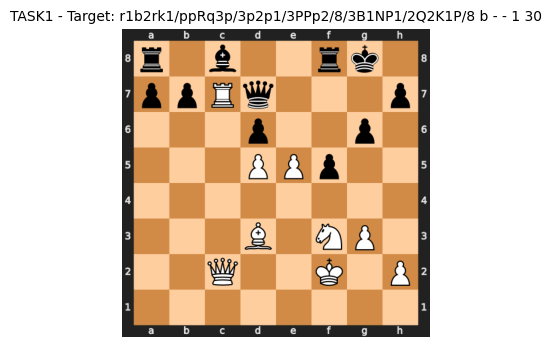

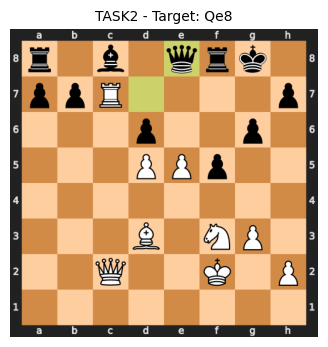

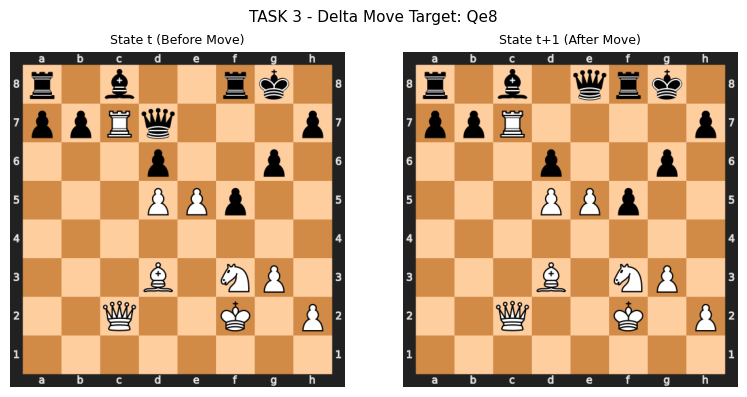

In [ ]:
print("\n=== VISUAL SAMPLE INSPECTION ===")

for task in tasks:
    split_dir = Path(f"dataset_{task}/train")
    jsonl_path = split_dir / "metadata.jsonl"
    if not jsonl_path.exists():
        continue

    # read first record form the json
    with open(jsonl_path, "r", encoding="utf-8") as f:
        meta = json.loads(f.readline())

    sample_id = meta.get("sample_id")
    sample_dir = split_dir / sample_id

    if task in ["task1", "task2"]:
        # Single image visualization
        img_path = split_dir / meta["file_name"]
        img = Image.open(img_path)

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"{task.upper()} - Target: {meta['target']}", fontsize=10)
        plt.show()

    elif task == "task3":
        # Dual-image pair visualization (State t and State t+1 side-by-side)
        img_t_path = split_dir / meta["file_name"]
        img_t1_path = split_dir / meta["file_name_t1"]

        img_t = Image.open(img_t_path)
        img_t1 = Image.open(img_t1_path)

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))
        axes[0].imshow(img_t)
        axes[0].set_title("State t (Before Move)", fontsize=9)
        axes[0].axis("off")

        axes[1].imshow(img_t1)
        axes[1].set_title("State t+1 (After Move)", fontsize=9)
        axes[1].axis("off")

        fig.suptitle(
            f"TASK 3 - Delta Move Target: {meta['target']}", fontsize=11, y=0.98
        )
        plt.tight_layout()
        plt.show()

Upload each dataset to Hugging Face

In [ ]:
api = HfApi()

print("\n==================== UPLOADING TO HUGGING FACE ====================\\")
for task in tasks:
  local_directory = f"dataset_{task}"
  remote_dataset_name = f"dataset_{task}"

  repo_id = f"{ORGANIZATION_NAME}/{remote_dataset_name}"

  print(f"Uploading folder {local_directory} to {repo_id} ...")

  api.upload_folder(
      folder_path=local_directory,
      repo_id=repo_id,
      repo_type="dataset",
      delete_patterns="**/metadata.json",
      commit_message=(
          f"Remove nested metadata.json and sync clean structure for {remote_dataset_name}"
      ),
  )

print("\nAll datasets have been synchronized successfully to Hugging Face!")


==================== UPLOADING TO HUGGING FACE ====================\
Uploading folder dataset_task1 to bdatm-project/dataset_task1 (syncing clean structure)...
Uploading folder dataset_task2 to bdatm-project/dataset_task2 (syncing clean structure)...
Uploading folder dataset_task3 to bdatm-project/dataset_task3 (syncing clean structure)...

All datasets have been synchronized successfully to Hugging Face!


# Evaluation

### Dataset

Dowloading datasets for all three tasks from Hugging Face

In [ ]:
# 1. Verify Authentication to Hugging Face once for all datasets
print("Verifying Authentication to Hugging Face...")
notebook_login()

# 2. Load Dataset Task 1
print("\n--- Processing Dataset Task 1 ---")
dataset_name_1 = "bdatm-project/dataset_task1"
print(f"Downloading dataset '{dataset_name_1}'...")

dataset_task1 = load_dataset(dataset_name_1)

print("Dataset Task 1 loaded successfully!")
print(dataset_task1)
print("Structure sample of train split - Task 1:", dataset_task1["train"][0])


# 3. Load Dataset Task 2
print("\n--- Processing Dataset Task 2 ---")
dataset_name_2 = "bdatm-project/dataset_task2"
print(f"Downloading dataset '{dataset_name_2}'...")

dataset_task2 = load_dataset(dataset_name_2)

print("Dataset Task 2 loaded successfully!")
print(dataset_task2)
print("Structure sample of train split - Task 2:", dataset_task2["train"][0])


# 4. Download Snapshot and Load Dataset Task 3
print("\n--- Processing Dataset Task 3 ---")
dataset_name_3 = "bdatm-project/dataset_task3"

# Download the entire dataset repository locally into a distinct folder
print("Downloading dataset snapshot locally...")
local_data_dir = snapshot_download(
    repo_id=dataset_name_3,
    repo_type="dataset",
    local_dir="./my_dataset_files_task3"
)

# Load the dataset structure via load_dataset
print(f"Loading dataset '{dataset_name_3}'...")
dataset_task3 = load_dataset(dataset_name_3)

# Loop through each split (train, validation, test) and map the second frame correctly
print("Mapping the dataset across splits to include image_t1...")
for split_name in dataset_task3.keys():

    def add_second_frame(example):
        # Build the path incorporating the split folder and file name
        file_path = os.path.join("./my_dataset_files_task3", split_name, example["file_name_t1"])
        example["image_t1"] = Image.open(file_path).convert("RGB")
        return example

    dataset_task3[split_name] = dataset_task3[split_name].map(add_second_frame)

print("Dataset Task 3 loaded and mapped successfully!")
print(dataset_task3)
print("Structure sample of train split - Task 3:", dataset_task3["train"][0])

print("\nAll three datasets have been successfully downloaded, loaded, and processed!")

## Model

TODO: description of the model, reasons why we used it

In [ ]:
model_id = "Qwen/Qwen3.5-0.8B"
print(f"Loading model {model_id}...")

model_vanilla = AutoModelForImageTextToText.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_id)
print("model and Processor loaded correctly!")

## Task 1

Testing model on a single sample

In [ ]:
# Grab the first test sample
test_sample = dataset_task1["test"][0]

fen = test_sample["fen"]
task_prompt = test_sample["prompt"]
ground_truth_fen = test_sample["target"]
sample_id = test_sample["sample_id"]
board_image = test_sample["image"]

print(f"Sample ID: {sample_id}")
print(f"FEN: {fen}")
print(f"Prompt provided to the model:\n{task_prompt}\n")
print(f"Real FEN (Ground Truth): {ground_truth_fen}\n")

# Prepare the multimodal input format for the model
chat_messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": board_image},
            {"type": "text", "text": task_prompt},
        ]
    }
]

# Apply the processor's chat template
formatted_text = processor.apply_chat_template(chat_messages, tokenize=False, add_generation_prompt=True)

# Tokenize inputs and move them to the GPU device
model_inputs = processor(
    text=[formatted_text],
    images=board_image,
    padding=True,
    return_tensors="pt"
).to(model_vanilla.device)

# Generate the zero-shot prediction
print("Generating zero-shot prediction...")
with torch.no_grad():
    output_token_ids = model_vanilla.generate(**model_inputs, max_new_tokens=128)

# Trim prompt tokens from the generated output
trimmed_output_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, output_token_ids)
]
predicted_fen_string = processor.batch_decode(
    trimmed_output_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0]

print(f"Predicted FEN (Zero-Shot): {predicted_fen_string.strip()}")

Testing vanilla model on the whole dataset 1 using the function *evaluate_chessboard_model_task_1* defined in *src/eval/utilities.py*

In [ ]:
# Call the evaluation function for the vanilla model
vanilla_results_df, vanilla_summary_df = evaluate_chessboard_model_task_1(
    model=model_vanilla,
    processor=processor,
    dataset_split=dataset_task1["test"],
    model_name="Vanilla Qwen3.5-0.8B (Zero-Shot)"
)

# Initialize the global comparison DataFrame with the vanilla results
all_models_results_task1 = vanilla_summary_df

print("\nExample of results obtained form the evaluation:")
display(vanilla_results_df.head())

print("\nComparative Summary DataFrame (all_models_results):")
display(all_models_results_task1)

### Lora Finetuning

We'll define 4 different models using a different patch ordering to analyze the image. To reorder the image patches we can use the function **get_patch_reordering_indices()** defined in *src/eval/utilities.py*

TODO: Explanation of all the strategies

PS: raster is the default -> right ot left and top to bottom

In [ ]:
strategies_to_train = ["raster", "zigzag", "spiral", "file_wise"]

for strat in strategies_to_train:
    order_map = get_patch_reordering_indices(strategy=strat)
    print(f"Strategy '{strat}' first 10 patch indices: {order_map[:10]}")

Defining finetuning parameters:

In [ ]:
peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    lora_dropout=0.05,
    bias="none",
)

Using function **finetune_and_push_chessboard_model()** to finetune all the 4 models. It is defined in *src/eval/utilities.py*

In [ ]:
trained_reordered_models = {}

for strat in strategies_to_train:
    trained_reordered_models[strat] = finetune_and_push_chessboard_model(
        strategy_name=strat,
        dataset=dataset_task1,
        processor=processor,
        peft_config=peft_config,
        task="task3",
    )

print("\nAll reordered models have been successfully trained and pushed to Hugging Face!")